# PCA + Clustering en Breast Cancer (sklearn)

Notebook reproducible que muestra un pipeline completo:
- Imputación de nulos (media)
- Estandarización
- PCA (análisis de dimensionalidad + reducción)
- Clusterización (K-Means y Gaussian Mixture)
- Métricas y visualizaciones


## 1) Imports y carga del dataset

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Config opcional: mostrar todas las columnas en outputs de pandas
pd.set_option('display.max_columns', 50)


In [14]:
# Cargar dataset Breast Cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0=malignant, 1=benign

X.shape, y.shape

((569, 30), (569,))

## 2) EDA breve

Objetivo: una inspección rápida del dataset (forma, nulos, resumen estadístico y distribución de clases).

In [15]:
print('Shape X:', X.shape)
print('Shape y:', y.shape)

display(X.head())
display(y.value_counts().rename(index={0:'malignant(0)', 1:'benign(1)'}))


Shape X: (569, 30)
Shape y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign(1)       357
malignant(0)    212
Name: count, dtype: int64

In [16]:
# Nulos (en este dataset normalmente no hay, pero lo medimos igual)
nulls_total = int(X.isna().sum().sum())
nulls_by_col = X.isna().sum().sort_values(ascending=False)
print('Total nulos en X:', nulls_total)
display(nulls_by_col.head(10))


Total nulos en X: 0


mean radius             0
mean texture            0
worst symmetry          0
worst concave points    0
worst concavity         0
worst compactness       0
worst smoothness        0
worst area              0
worst perimeter         0
worst texture           0
dtype: int64

In [17]:
# Resumen estadístico (vista rápida)
display(X.describe().T.head(12))

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 3) Preprocesamiento: imputación + estandarización

1) Si existieran valores nulos: imputación por media.
2) Estandarización: media 0 y desviación estándar 1 (necesario para PCA con features en distintas escalas).

In [18]:
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print('Nulos después de imputar:', int(X_imputed.isna().sum().sum()))
print('X_scaled shape:', X_scaled.shape)

Nulos después de imputar: 0
X_scaled shape: (569, 30)


## 4) PCA: análisis de dimensionalidad

Ajustamos PCA con todas las componentes para inspeccionar la **varianza explicada** y la **varianza acumulada**.

Luego elegimos el menor número de componentes que explique al menos **95%** de la varianza.

In [19]:
random_state = 42

pca_full = PCA(n_components=None, random_state=random_state)
X_pca_full = pca_full.fit_transform(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

threshold = 0.95
k_95 = int(np.argmax(cum_explained_var >= threshold) + 1)

k_95, cum_explained_var[k_95-1]

(10, np.float64(0.951568814336667))

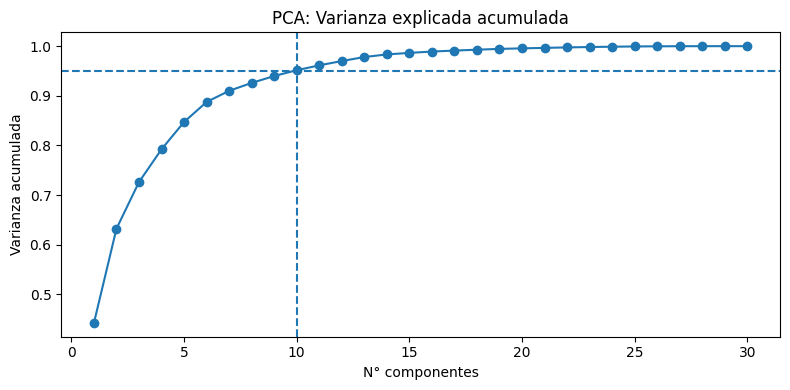

In [20]:
# Curva de varianza explicada acumulada
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cum_explained_var) + 1), cum_explained_var, marker='o')
plt.axhline(threshold, linestyle='--')
plt.axvline(k_95, linestyle='--')
plt.title('PCA: Varianza explicada acumulada')
plt.xlabel('N° componentes')
plt.ylabel('Varianza acumulada')
plt.tight_layout()
plt.show()


## 5) Reducción de dimensionalidad con PCA

Aplicamos PCA con `k_95` componentes y mostramos el dataset **antes** (imputado) y **después** (componentes principales).

In [21]:
pca = PCA(n_components=k_95, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(k_95)], index=X.index)

print('Antes de PCA (imputado):', X_imputed.shape)
display(X_imputed.head())

print('Después de PCA:', X_pca_df.shape)
display(X_pca_df.head())


Antes de PCA (imputado): (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Después de PCA: (569, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,1.411424,2.159370,-0.398407,-0.157118,-0.877402
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,0.028656,0.013358,0.240988,-0.711905,1.106995
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,0.541452,-0.668166,0.097374,0.024066,0.454275
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,3.053422,1.429911,1.059565,-1.405440,-1.116975
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,-1.226495,-0.936213,0.636376,-0.263805,0.377704


In [34]:
# identificar y mostrar las variables seleccionadas para PCA y el peso de cada una de ellas en las componentes principales
loadings = pd.DataFrame(pca.components_.T, index=X.columns)
display(loadings.head(10))

,0,1,2,3,4,5,6,7,8,9
mean radius,0.218902,-0.233857,-0.008531,-0.041409,-0.037786,0.018741,-0.124088,-0.007452,-0.223110,0.095486
mean texture,0.103725,-0.059706,0.064550,0.603050,0.049469,-0.032179,0.011400,0.130675,0.112699,0.240934
mean perimeter,0.227537,-0.215181,-0.009314,-0.041983,-0.037375,0.017308,-0.114477,-0.018687,-0.223739,0.086386
mean area,0.220995,-0.231077,0.028700,-0.053434,-0.010331,-0.001888,-0.051653,0.034674,-0.195586,0.074956
mean smoothness,0.142590,0.186113,-0.104292,-0.159383,0.365089,-0.286374,-0.140669,-0.288975,0.006425,-0.069293
mean compactness,0.239285,0.151892,-0.074092,-0.031795,-0.011704,-0.014131,0.030918,-0.151396,-0.167841,0.012936
mean concavity,0.258400,0.060165,0.002734,-0.019123,-0.086375,-0.009344,-0.107520,-0.072827,0.040591,-0.135602
mean concave points,0.260854,-0.034768,-0.025564,-0.065336,0.043861,-0.052050,-0.150482,-0.152322,-0.111971,0.008055
mean symmetry,0.138167,0.190349,-0.040240,-0.067125,0.305941,0.356458,-0.093891,-0.231531,0.256040,0.572069
mean fractal dimension,0.064363,0.366575,-0.022574,-0.048587,0.044424,-0.119431,0.295760,-0.177121,-0.123741,0.081103


**IMPORTANTE**

PCA no “selecciona” features, sino que construye combinaciones lineales.
Lo correcto es analizar los loadings (pesos de cada feature en cada CP).

In [35]:
# detectar cual es la característica más dominante en cada componente principal
dominant_features = loadings.abs().idxmax()
dominant_features


0        mean concave points
1     mean fractal dimension
2              texture error
3              worst texture
4            mean smoothness
5             worst symmetry
6    worst fractal dimension
7           smoothness error
8            concavity error
9              mean symmetry
dtype: object

**Importante**

Esto no significa que la CP sea ese feature, sino que ese feature explica la mayor parte de la varianza en esa CP.
PCA combina features; los **loadings** indican su contribución.

## 6) Clusterización (K-Means y Gaussian Mixture)

Clustering sobre el espacio PCA. Usamos `n_clusters=2` porque el target real es binario.

In [36]:
n_clusters = 2

# K-Means
kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=random_state)
km_labels = kmeans.fit_predict(X_pca)

# Gaussian Mixture
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=random_state)
gmm_labels = gmm.fit_predict(X_pca)

pd.Series(km_labels).value_counts(), pd.Series(gmm_labels).value_counts()

(0    380
 1    189
 Name: count, dtype: int64,
 1    405
 0    164
 Name: count, dtype: int64)

## 7) Métricas

- **Silhouette**: cohesión/separación de clusters (no supervisada).
- **ARI / NMI**: medida de alineación con segmentos reales (`y`), robusta a permutación de etiquetas.

In [ ]:
sil_km = silhouette_score(X_pca, km_labels)
sil_gmm = silhouette_score(X_pca, gmm_labels)

ari_km = adjusted_rand_score(y, km_labels)
ari_gmm = adjusted_rand_score(y, gmm_labels)

nmi_km = normalized_mutual_info_score(y, km_labels)
nmi_gmm = normalized_mutual_info_score(y, gmm_labels)

metrics = pd.DataFrame({
    'modelo': ['KMeans', 'GMM'],
    'silhouette': [sil_km, sil_gmm],
    'ARI': [ari_km, ari_gmm],
    'NMI': [nmi_km, nmi_gmm],
})
metrics

,modelo,silhouette,ARI,NMI
0,KMeans,0.357986,0.670721,0.554612
1,GMM,0.262947,0.134187,0.075869


## 8) Gráficos comparativos (3 en 1 columna)

Comparamos en el plano **PC1 vs PC2**:
1) K-Means
2) Gaussian Mixture
3) Segmentos reales

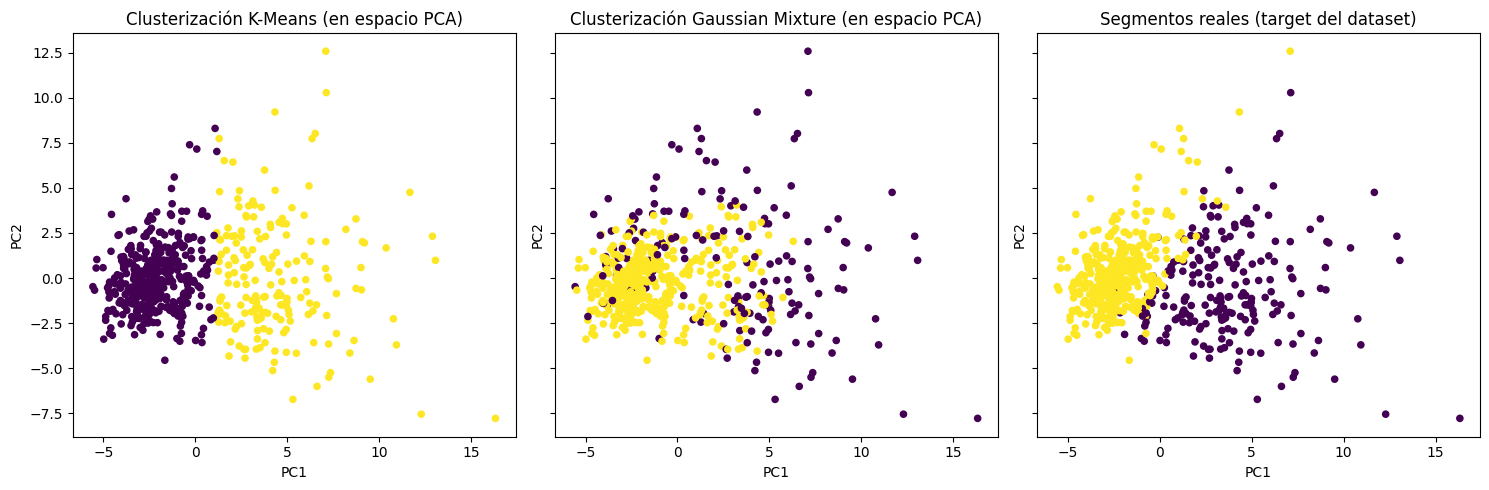

In [ ]:
if k_95 < 2:
    raise ValueError('PCA devolvió menos de 2 componentes; se requieren PC1 y PC2 para graficar.')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=km_labels, s=20)
axes[0].set_title('Clusterización K-Means (en espacio PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=gmm_labels, s=20)
axes[1].set_title('Clusterización Gaussian Mixture (en espacio PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

axes[2].scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=y, s=20)
axes[2].set_title('Segmentos reales (target del dataset)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()
